Hello, and welcome to my week 4 assignment. This week, our focus is on using the pandas library in Python to clean and manipulate data sets for later usage. This is a valuable skillset that I only previously learned in R, so I look forward to experimenting with this data wrangling methods using Python. Let's start first by setting up our libraries:

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import warnings
warnings.filterwarnings('ignore')
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

**Part 1: Read In Dataset**

For this week's dataset, we'll use a dataset of Fantasy English Premiere League statistics. For context, English Premiere League is the largest professional soccer league in the world. Fans of the sport can participate in Fantasy Football (I specifically chose this dataset because I noticed the user provides both a master index dataset as well as a merged data set. This guarantees that there will at least be some aspects of the data set that require cleaning/wrangling, so we'll use the mergeddataset CSV file as our base dataset. Let's import the data set:

In [87]:
fantasy_data = pd.read_csv('mergeddataset.csv')

fantasy_data.head(10)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1.0,0.0,1,0,0,0,45,True,1,1
5,2016-17,Adam Lallana,MID,NaN,1,2,33,0,33.7,205,...,3.0,57.0,11,0,0,0,70,False,1,1
6,2016-17,Adam Smith,DEF,NaN,0,0,23,0,4.3,34,...,1.0,27.0,7,0,0,0,45,True,0,1
7,2016-17,Adrián San Miguel del Castillo,GK,NaN,0,0,16,0,0.0,450,...,2.0,0.0,2,0,0,0,50,False,0,1
8,2016-17,Alex Iwobi,MID,NaN,1,0,12,0,17.5,21,...,3.0,0.0,3,0,0,0,60,True,1,1
9,2016-17,Alex McCarthy,GK,NaN,0,0,0,0,0.0,101,...,1.0,0.0,0,0,0,0,45,True,0,1


**Part 2: Clean the Dataset**

Initially, looking at our dataset, we observe around 96,000 separate observations of individual player performances in matches spanning from 2016-2022. Here are the procedures I'd like to apply to clean this data:

1. The creator of the dataset attempted to merge a master data set of EPL team names with this dataset, but it appears to have only been successful for teams past the 2020 mark; the rest of the team_x column values before that date are all empty (NaN). I'd like to remove those values so we can do operations by grouping players by team, essentially shortening our dataset to the 2020-2022 season range.
2. I'd like to also do grouping by position and team, so we'll turn the position and team columns into categorical factor variables.
3. Melt or pivot our dataset to view some crucial statistics of distributions, such as mean and spread

Let's start first with cleaning the dataset of NaN values in the team_x column, then turning it into a categorical factor variable (we'll do the same with position):

In [88]:
cleaned_fantasy_data = fantasy_data.dropna(subset = ['team_x'])


team_names = [
    "Arsenal",
    "Bournemouth",
    "Burnley",
    "Chelsea",
    "Crystal Palace",
    "Everton",
    "Hull",
    "Leicester",
    "Liverpool",
    "Man City",
    "Man Utd",
    "Middlesbrough",
    "Southampton",
    "Stoke",
    "Sunderland",
    "Swansea",
    "Spurs",
    "Watford",
    "West Brom",
    "West Ham",
    "Brighton",
    "Huddersfield",
    "Newcastle",
    "Cardiff",
    "Fulham",
    "Wolves",
    "Aston Villa",
    "Norwich",
    "Sheffield Utd",
    "Leeds",
    "Brentford",
    "Nott'm Forest",
]

position_names = ['GK', 'DEF', 'MID', 'FWD']

cleaned_fantasy_data['team_x'] = pd.Categorical(cleaned_fantasy_data['team_x'], categories = team_names)
cleaned_fantasy_data['position'] = pd.Categorical(cleaned_fantasy_data['position'], categories = position_names)
cleaned_fantasy_data.head(15)

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
19852,2020-21,Aaron Connolly,FWD,Brighton,0,0,-3,0,0.3,78,...,1.0,32.0,1,0,0,0,55,True,0,1
19853,2020-21,Aaron Cresswell,DEF,West Ham,0,0,11,0,11.2,435,...,0.0,0.0,1,0,0,0,50,True,0,1
19854,2020-21,Aaron Mooy,MID,Brighton,0,0,0,0,0.0,60,...,1.0,0.0,0,0,0,0,50,True,0,1
19855,2020-21,Aaron Ramsdale,GK,Sheffield Utd,0,0,12,0,0.0,483,...,0.0,0.0,1,0,0,0,50,True,0,1
19856,2020-21,Abdoulaye Doucouré,MID,Everton,0,0,20,1,44.6,512,...,0.0,4.0,3,0,0,0,55,False,0,1
19857,2020-21,Aboubakar Kamara,MID,Fulham,0,0,-2,0,1.8,190,...,0.0,5.0,2,0,0,0,50,True,0,1
19858,2020-21,Adama Traoré,MID,Wolves,0,0,6,1,1.8,465,...,0.0,17.0,3,0,0,0,65,False,0,1
19859,2020-21,Adam Forshaw,MID,Leeds,0,0,0,0,0.0,199,...,4.0,0.0,0,0,0,0,50,False,0,1
19860,2020-21,Adam Lallana,MID,Brighton,0,0,6,0,27.2,54,...,1.0,2.0,1,0,0,0,65,True,0,1
19861,2020-21,Adam Webster,DEF,Brighton,0,0,14,0,11.8,66,...,1.0,1.0,1,0,0,0,45,True,0,1


**Part 3: Assists and Goals By Position**

Now that our data is cleaned of empty values and we've changed some columns to have more apt classifications, we can finally start grouping our data and doing some visualizations. The first aggregation I'd like to do is group players by their position (goalkeeper, defender, midfielder, and forward), and visualize the differences in some key statistics (goals and assists) for soccer players, so let's take a look:

In [1]:
selected_fantasy_data = cleaned_fantasy_data[['position', 'assists', 'goals_scored']]


by_position = selected_fantasy_data.groupby('position')[['assists', 'goals_scored']].agg('mean')

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=False)

sns.barplot(data = by_position, x = 'position', y = 'assists', ax = axes[0])
axes[0].set_title('Avg. Ass. Per Game For Indiv. Player by Pos., EPL 2020-22')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Average Assists Per Game')

sns.barplot(data = by_position, x = 'position', y = 'goals_scored', ax = axes[1])
axes[1].set_title('Avg. Goals Per Game For Indiv. Player by Pos., EPL 2020-22')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Average Goals Scored Per Game')

plt.show()


NameError: name 'cleaned_fantasy_data' is not defined

**Part 4: Creativity and Threat by Club**

Assists and goals are usually are best way of quantifying a soccer player's offensive output, at least as it pertains to putting points on the board. Here, we see a distribution that we'd generally expect, as average goals and assists per game rises for an individual player if they play a more offensively involved position; the positions are ordered from furthest back on the field to furthest up. It's interesting to note how midfielders and forwards have basically equal involvement in playmaking, yet no other position scores even close to the amount of goals as forwards do.

Now, let's group by club, and view two interesting stats: Creativity and Threat. Creativity measures a player's ability to execute unusual plays, such as difficult passes or technical dribble moves, that lead to offensive opportunities; threat measures the probability of a player's actions resulting in a goal in the near future. By comparing the average of these two stats across clubs and representing their relationship using a scatterplot, we'll be able to view which teams play the most daringly, as well as which ones are actually rewarded for their playstyle:

In [92]:
by_team

,team_x,creativity,threat
0,Arsenal,4.655878,5.278639
1,Bournemouth,2.874832,3.082151
2,Burnley,3.699605,4.236068
3,Chelsea,5.401234,5.656336
4,Crystal Palace,3.618809,4.078010
5,Everton,3.382128,3.843589
6,Leicester,4.120437,4.559013
7,Liverpool,5.760813,6.649297
8,Man City,6.554151,7.427600
9,Man Utd,4.961770,5.088502


In [93]:
selected_fantasy_data_2 = cleaned_fantasy_data[['team_x', 'creativity', 'threat']]

by_team = selected_fantasy_data_2.groupby('team_x')[['creativity', 'threat']].agg('mean')
by_team = by_team.reset_index()

alt.Chart(by_team).mark_circle().encode(
    x='creativity:Q',
    y='threat:Q',
    color='team_x:N',
    tooltip= [alt.Tooltip('team_x', title = 'Team'), 'creativity', 'threat']
).interactive()

alt.Chart(...)

Here, we observe two very interesting things. Firstly, there appears to be a **very strong** positive linear correlation between creativity and threat; seeing as the two go hand in hand, this shouldn't entirely shock us. In fact, much of a team's threat value is likely related to events that are considered statistically creative: tight-knit passes through several lines of defense, nifty dribble moves to get past defenders, and plays that lead to high probability of a goal scoring should have some quantitative value to both our creativity and our threat stats. Secondly, we notice that the three leaders in both creativity in threat, being Man City, Liverpool, and Chelsea, are some of the top goal scoring clubs on a year-to-year basis in the EPL. In fact, they are ranked 2nd, 8th, and 4th respectively in goals scored so far in the 2026-27 EPL season. In the future, I'd like to merge this dataset with another vector that describes goals scored per game, and pursue the possibility of correlation between these three statistics.

**Part 5: Melting and Pivoting the By Team Dataset**

We want to convert our by_team dataset to wide format, so that we can see team names as labels and two separate rows for creativity and threat; this makes it easier to directly compare the values for each team. We'll first melt the table by combining our two statistic columns into one (becoming a "Statistic" column, paired with an extra column for "Value"), then pivot it into a wider table. Finally, we'll create a heat map to have another visual comparison of creativity and threat.

<Axes: xlabel='team_x', ylabel='Statistic'>

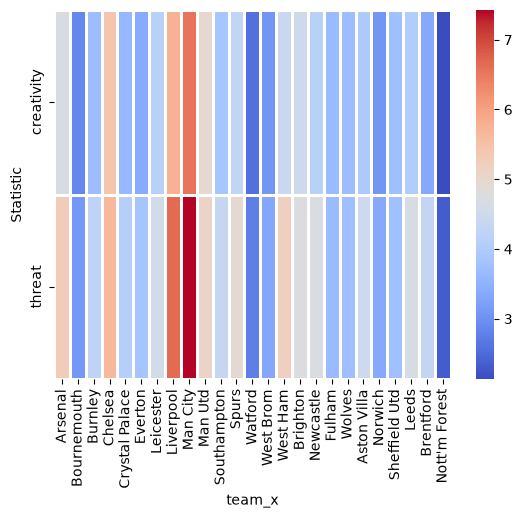

In [91]:
by_team_long = by_team.melt(id_vars = 'team_x', var_name = 'Statistic', value_name = 'Value')
by_team_pivot = by_team_long.pivot(index='Statistic', columns='team_x', values='Value')

sns.heatmap(by_team_pivot, linewidth = 1, linecolor = 'white', cmap = 'coolwarm')

While a heatmap is just another form of visualizing the relationship between two quantitative variables across a categorical variable, I find the side by side comparisons to be more striking. For example, Man City's offensive dominance is far more apparent in the heat chart than in the scatter plot (I purposely chose a high contrast color palette for this reason); this is especially powerful, given Man City is the only team that has currently won all of their matches so far in the 2026-27 EPL season. Furthermore, direct comparison of threat and creativity for a club is far more apparent when visualized in a heat chart, as these two metrics share a scale and are often added together to calculate player impact. When considering holistic player impact, this heat chart is a very helpful tool to understand how exactly that impact is broken up. A main takeaway from this chart is that a team that is ambitious/creative and can actually take advantage of unexpected opportunities is likely to have dominant stretches, much like the one Man City is on currently.

**Conclusion**

In all, this was a super helpful exercise in data wrangling, one that is specifically productive for me as I am primarily an R user. Many of the methods of wrangling in Python are easier and to some degree more intuitive (such as selecting or creating new columns, less complicated than mutate() in R), and it lends itself well to some of Python's strongs visual tools, such as melting and pivoting a table so that we can use a heatchart. Overall, I look forward to continuing to use Python in a more holistical way rather than just for visualization.